## IMPORT

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## 1. Dataset Exploration

In [2]:
df = pd.read_csv(r"C:\Users\ngarg\Downloads\train1.csv")
df.head(5)

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
df.shape

(42000, 785)

In [5]:
df['label'].nunique()

10

In [6]:
df['label'].value_counts()

label
1    4684
7    4401
3    4351
9    4188
2    4177
6    4137
0    4132
4    4072
8    4063
5    3795
Name: count, dtype: int64

In [7]:
df.isnull().sum()

label       0
pixel0      0
pixel1      0
pixel2      0
pixel3      0
           ..
pixel779    0
pixel780    0
pixel781    0
pixel782    0
pixel783    0
Length: 785, dtype: int64

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42000 entries, 0 to 41999
Columns: 785 entries, label to pixel783
dtypes: int64(785)
memory usage: 251.5 MB


In [9]:
df.describe()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
count,42000.000000,42000.0,42000.0,42000.0,42000.0,42000.0,42000.0,42000.0,42000.0,42000.0,...,42000.000000,42000.000000,42000.000000,42000.00000,42000.000000,42000.000000,42000.0,42000.0,42000.0,42000.0
mean,4.456643,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.219286,0.117095,0.059024,0.02019,0.017238,0.002857,0.0,0.0,0.0,0.0
std,2.887730,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,6.312890,4.633819,3.274488,1.75987,1.894498,0.414264,0.0,0.0,0.0,0.0
min,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0
25%,2.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0
50%,4.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0
75%,7.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0
max,9.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,254.000000,254.000000,253.000000,253.00000,254.000000,62.000000,0.0,0.0,0.0,0.0


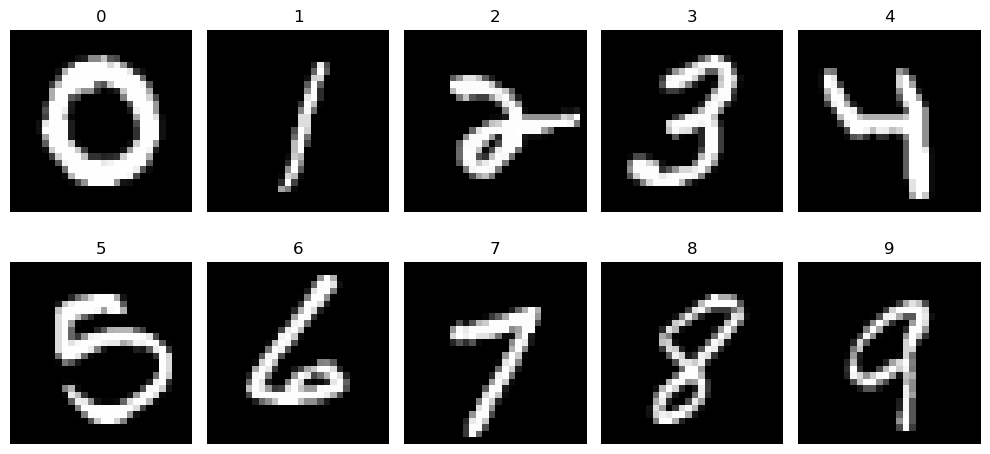

In [10]:
fig, axes = plt.subplots(2, 5, figsize=(10, 5))

indices = [1, 15, 34, 70, 921, 1081, 998, 961, 1026, 41999]

for ax, idx in zip(axes.ravel(), indices):
    sample = df.iloc[idx]
    label = sample['label']
    image = sample.drop('label').values.reshape(28, 28)

    ax.imshow(image, cmap='grey')
    ax.set_title(f"{label}")
    ax.axis('off')

plt.tight_layout()
plt.show()

## 2. Data Preprocessing

In [3]:
x = df.drop(columns = ['label'])
y = df['label']

In [4]:
x = (x / 254).astype(np.float32)

In [5]:
x.shape

(42000, 784)

## 3. Perceptron

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score , confusion_matrix , classification_report
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42 ,stratify=y)

In [15]:
from sklearn.linear_model import Perceptron
modelPer = Perceptron(max_iter=1000 , random_state= 42)
modelPer.fit(X_train , y_train)
y_predict = modelPer.predict(X_test)
accuracy = accuracy_score(y_test , y_predict)
accuracy

0.871031746031746

In [16]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'alpha': [0.0001, 0.001, 0.01],
    'penalty': ['l2', 'l1', 'elasticnet'],
    'max_iter': [1000, 2000, 3000],
    'eta0': [0.1, 1.0, 10.0]
}

search = RandomizedSearchCV(
    modelPer,
    param_distributions=param_dist,
    n_iter=10,
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train)

,estimator,Perceptron(random_state=42)
,param_distributions,"{'alpha': [0.0001, 0.001, ...], 'eta0': [0.1, 1.0, ...], 'max_iter': [1000, 2000, ...], 'penalty': ['l2', 'l1', ...]}"
,n_iter,10
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [17]:
print(search.best_params_)
print(search.best_score_)

{'penalty': 'l2', 'max_iter': 1000, 'eta0': 0.1, 'alpha': 0.0001}
0.865986394557823


In [18]:
best_model = search.best_estimator_
y_pred = best_model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8668253968253968


In [19]:
cm = confusion_matrix(y_test, y_pred)

labels = [0,1,2,3,4,5,6,7,8,9]
cm_df = pd.DataFrame(cm, index=labels, columns=labels)
cm_df.index.name = "Actual"
cm_df.columns.name = "Predicted"
cm_df

Predicted,0,1,2,3,4,5,6,7,8,9
Actual,,,,,,,,,,
0,1171,0,18,3,6,25,16,0,1,0
1,0,1361,21,4,1,1,3,5,5,4
2,1,9,1171,13,13,11,14,13,6,2
3,3,6,80,1100,4,67,17,7,5,16
4,2,6,31,1,1101,6,18,5,3,49
5,15,9,20,52,32,944,29,8,17,13
6,4,5,23,2,4,24,1175,1,3,0
7,9,7,47,22,11,1,8,1138,0,77
8,12,48,165,57,15,84,31,13,753,41


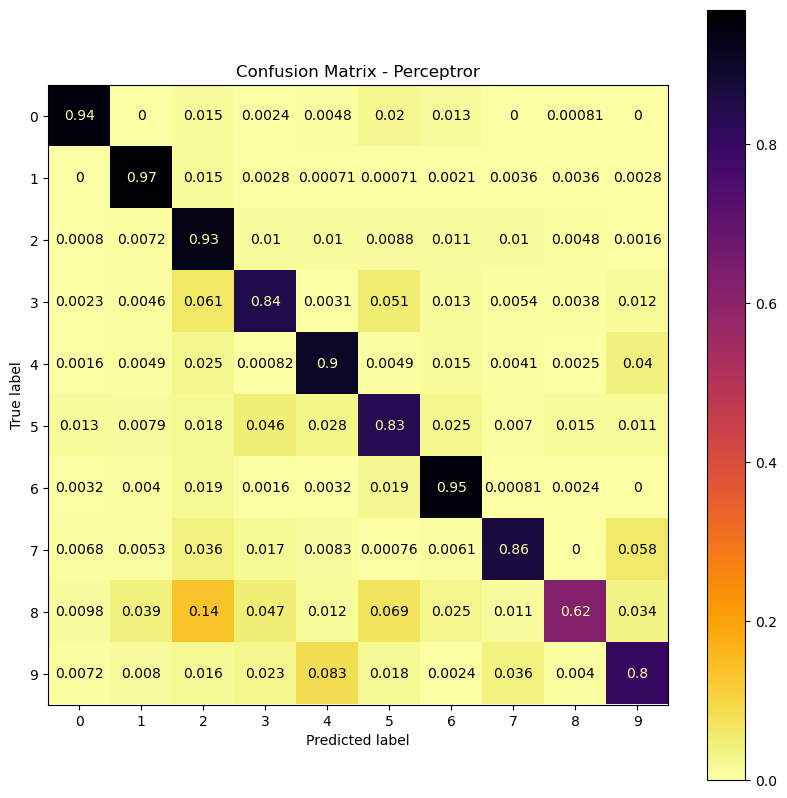

In [20]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(10,10))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="inferno_r",
    normalize="true", 
    ax=ax
)

plt.title("Confusion Matrix - Perceptror")
plt.show()

In [21]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.94      0.95      1240
           1       0.93      0.97      0.95      1405
           2       0.73      0.93      0.82      1253
           3       0.86      0.84      0.85      1305
           4       0.85      0.90      0.88      1222
           5       0.80      0.83      0.81      1139
           6       0.89      0.95      0.92      1241
           7       0.92      0.86      0.89      1320
           8       0.94      0.62      0.75      1219
           9       0.83      0.80      0.82      1256

    accuracy                           0.87     12600
   macro avg       0.87      0.86      0.86     12600
weighted avg       0.87      0.87      0.87     12600



# Results and Observation (Perceptron Model)

## 1. Model Performance

The Perceptron model was trained using RandomizedSearchCV with cross-validation for hyperparameter tuning. The final model achieved an accuracy of approximately **0.866 (86.6%)**, while the classification report shows an overall weighted accuracy of approximately **0.87**.

---

## 2. Classification Report Analysis

The classification report shows variation in performance across different digit classes. Digits such as **0, 1, and 6** achieved high precision and recall values (above 0.90), indicating strong classification performance.

However, digits such as **2, 5, 8, and 9** show comparatively lower performance. In particular, digit **8 has the lowest recall (0.62)**, indicating that many samples of digit 8 are misclassified as other digits.

Overall, the macro average F1-score is approximately **0.86**, while the weighted average F1-score is approximately **0.87**, indicating moderate but consistent performance across the dataset.

---

## 3. Confusion Matrix Analysis

The confusion matrix confirms that the model performs well on simpler digits but struggles with visually similar digits.

- Digit **0 and 1** are mostly correctly classified.
- Digit **8 is frequently misclassified**, especially as 2, 3, 5, and 9.
- Digit **5 and 9** also show noticeable confusion with other similar digits.

This indicates that certain handwritten digit shapes overlap in feature space, making them difficult for a linear classifier like Perceptron to distinguish.

---

## 4. Final Observation

The Perceptron model achieves moderate performance on the MNIST dataset. However, it struggles with complex and non-linearly separable digit patterns due to its linear decision boundary limitation.

While hyperparameter tuning improves stability, it does not significantly overcome the inherent limitations of the model.

---

## 5. Code Output Summary

- Best Model Accuracy (CV tuned): **0.866**
- Test Accuracy: **0.8668**
- Weighted F1-score: **0.87**